In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import shutil
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, UpSampling2D, Concatenate, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import csv
import zipfile

tf.get_logger().setLevel('ERROR')


ModuleNotFoundError: No module named 'tqdm'

In [ ]:
DATA_ROOT = "/kaggle/input/tusimple/TUSimple"
CLIPS_PATH = f"/kaggle/input/tusimple/TUSimple/train_set/clips"
PROCESSED_IMGS = "/kaggle/working/processed_images"
MASK_STORAGE = "/kaggle/working/mask_images"
TEST_INPUT = f"/kaggle/input/tusimple/TUSimple/test_set/clips/0530/1492626047222176976_0"
VIDEO_SAVE = "/kaggle/working/output_video/lane_output.mp4"

os.makedirs(PROCESSED_IMGS, exist_ok=True)
os.makedirs(MASK_STORAGE, exist_ok=True)
os.makedirs(os.path.dirname(VIDEO_SAVE), exist_ok=True)

In [ ]:
json_files = [
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0313.json",
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0531.json",
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0601.json"
]
data_frame = pd.concat([pd.read_json(f, lines=True) for f in json_files], ignore_index=True)

In [ ]:
import os
def gather_images():
    if os.listdir(PROCESSED_IMGS):  # Skip if already processed
        return
    for raw_path in tqdm(data_frame['raw_file'], desc="Copying images"):
        clean_path = raw_path.replace('\\', '/')
        src = os.path.join(DATA_ROOT, "train_set", clean_path)  # <- this is the real path

        if os.path.isfile(src):
            clip, frame = clean_path.split('/')[-2:]

            
            new_name = f"{clip}_{frame}"
            dst = os.path.join(PROCESSED_IMGS, new_name)
            shutil.copy(src, dst)

gather_images()

Copying images: 100%|██████████| 3626/3626 [00:31<00:00, 113.38it/s]


In [ ]:

def build_masks(dataset):
    if os.listdir(MASK_STORAGE):
        return
    for _, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Building masks"):
        mask = np.zeros((720, 1280), dtype=np.uint8)
        lanes = row['lanes']
        ys = row['h_samples']
        raw_path = row['raw_file'].replace('\\', '/')
        for lane in lanes:
            pts = [(x, y) for x, y in zip(lane, ys) if x >= 0]
            if pts:
                pts = np.array(pts, dtype=np.int32)
                cv2.polylines(mask, [pts], False, 255, thickness=8)
        clip, frame = raw_path.split('/')[-2:]
        name = f"{clip}_{frame}"
        cv2.imwrite(os.path.join(MASK_STORAGE, name), mask)
        

build_masks(data_frame)

Building masks: 100%|██████████| 3626/3626 [00:06<00:00, 531.58it/s]


In [ ]:
print("Images:", sorted(os.listdir(PROCESSED_IMGS))[:5])
print("Masks:", sorted(os.listdir(MASK_STORAGE))[:5])

image_filenames = sorted(os.listdir(PROCESSED_IMGS))
mask_filenames = sorted(os.listdir(MASK_STORAGE))

common = set(image_filenames) & set(mask_filenames)
print("Common filenames:", list(common)[:5])  # ✅ should not be empty now

img_paths = [os.path.join(PROCESSED_IMGS, f) for f in common]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in common]


Images: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']
Masks: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']
Common filenames: ['39660_20.jpg', '58560_20.jpg', '1494452463561061228_20.jpg', '28980_20.jpg', '1494452427576086954_20.jpg']


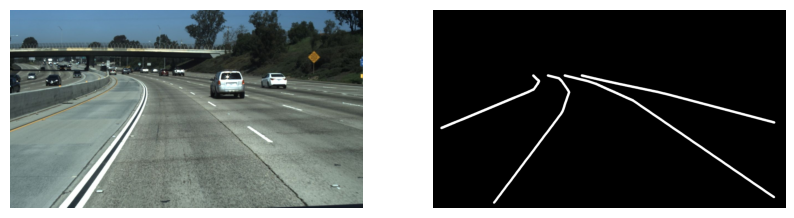

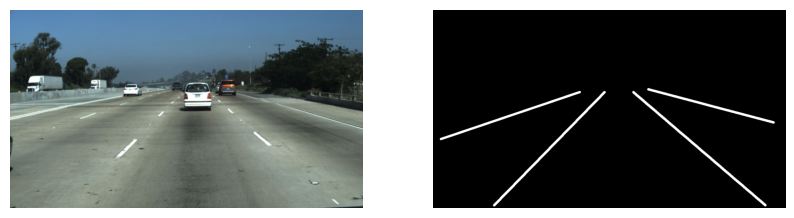

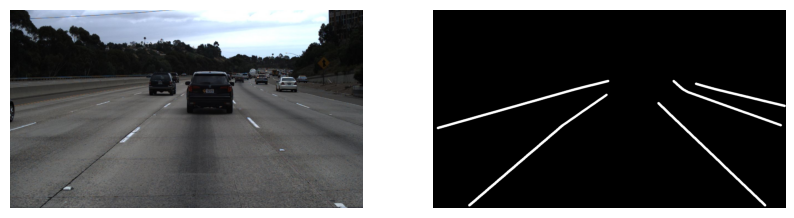

In [ ]:
def display_samples(count=3):
    names = os.listdir(PROCESSED_IMGS)
    if not names:
        return
    selected = np.random.choice(names, min(count, len(names)), replace=False)
    for name in selected:
        img = cv2.cvtColor(cv2.imread(os.path.join(PROCESSED_IMGS, name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(MASK_STORAGE, name), cv2.IMREAD_GRAYSCALE)
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        plt.show()

display_samples()


In [ ]:
image_filenames = sorted(os.listdir(PROCESSED_IMGS))
mask_filenames = sorted(os.listdir(MASK_STORAGE))

# Keep only files that exist in both
common = set(image_filenames) & set(mask_filenames)
common = sorted(common)

img_paths = [os.path.join(PROCESSED_IMGS, f) for f in common]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in common]

print("Total paired samples:", len(img_paths))


Total paired samples: 2910


In [ ]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Dropout, UpSampling2D, Concatenate
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model

def construct_network(input_size=(224, 224, 3)):
    def block(filters, x):
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(0.3)(x)
        return x

    # Load ResNet50 from local weights instead of downloading
    base = ResNet50(weights=None, include_top=False, input_shape=input_size)
    base.load_weights("/kaggle/input/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5")

    for layer in base.layers:
        layer.trainable = True

    i = base.input
    f1 = base.get_layer('conv1_relu').output
    f2 = base.get_layer('conv2_block3_out').output
    f3 = base.get_layer('conv3_block4_out').output
    f4 = base.get_layer('conv4_block6_out').output
    f5 = base.get_layer('conv5_block3_out').output

    u1 = UpSampling2D(2)(f5)
    m1 = Concatenate()([u1, f4])
    c1 = block(512, m1)

    u2 = UpSampling2D(2)(c1)
    m2 = Concatenate()([u2, f3])
    c2 = block(256, m2)

    u3 = UpSampling2D(2)(c2)
    m3 = Concatenate()([u3, f2])
    c3 = block(128, m3)

    u4 = UpSampling2D(2)(c3)
    m4 = Concatenate()([u4, f1])
    c4 = block(64, m4)

    out = UpSampling2D(2)(c4)
    out = Conv2D(1, 1, activation='sigmoid')(out)
    return Model(i, out)

# Create model
network = construct_network()


I0000 00:00:1764473280.031885      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
def dice(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    i = tf.reduce_sum(y_true * y_pred)
    return (2. * i + 1.) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1.)

def loss(y_true, y_pred):
    return 1. - dice(y_true, y_pred)

def precision(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    tp = tf.reduce_sum(y_true * y_pred)
    return tp / (tf.reduce_sum(y_pred) + tf.keras.backend.epsilon())

def recall(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    tp = tf.reduce_sum(y_true * y_pred)
    return tp / (tf.reduce_sum(y_true) + tf.keras.backend.epsilon())

network.compile(optimizer='adam', loss=loss, metrics=[dice, precision, recall, 'accuracy'])

In [ ]:
def prepare_data(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, [224, 224], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


img_paths = [os.path.join(PROCESSED_IMGS, f) for f in os.listdir(PROCESSED_IMGS)]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in os.listdir(MASK_STORAGE)]

train_imgs, val_imgs, train_masks, val_masks = train_test_split(img_paths, mask_paths, test_size=0.2, random_state=42)

train_set = tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
train_set = train_set.map(prepare_data, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)

val_set = tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))
val_set = val_set.map(prepare_data, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
print("Images:", len(img_paths))
print("Masks:", len(mask_paths))


Images: 2910
Masks: 2910


Epoch 1/15


I0000 00:00:1764473335.864773     103 service.cc:148] XLA service 0x7985e80ba930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764473335.865527     103 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764473340.762147     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/291 ━━━━━━━━━━━━━━━━━━━━ 6:45:24 84s/step - accuracy: 0.2849 - dice: 0.0435 - loss: 0.9565 - precision: 0.0225 - recall: 0.6515

I0000 00:00:1764473368.002862     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8929 - dice: 0.2899 - loss: 0.7101 - precision: 0.2010 - recall: 0.7764

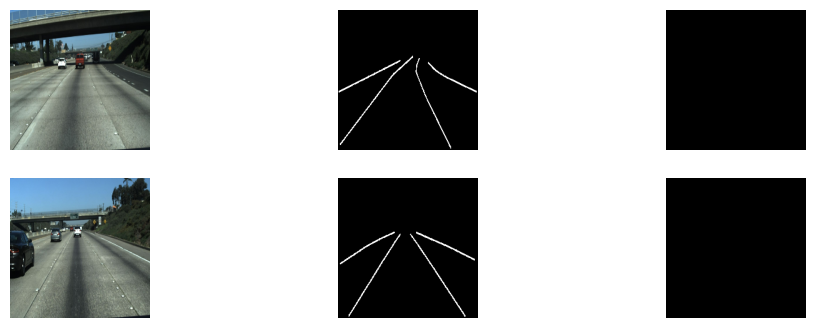

291/291 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.8931 - dice: 0.2903 - loss: 0.7097 - precision: 0.2015 - recall: 0.7762 - val_accuracy: 0.9727 - val_dice: 7.9657e-04 - val_loss: 0.9992 - val_precision: 0.0205 - val_recall: 3.4786e-04
Epoch 2/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9707 - dice: 0.5593 - loss: 0.4407 - precision: 0.4847 - recall: 0.6624

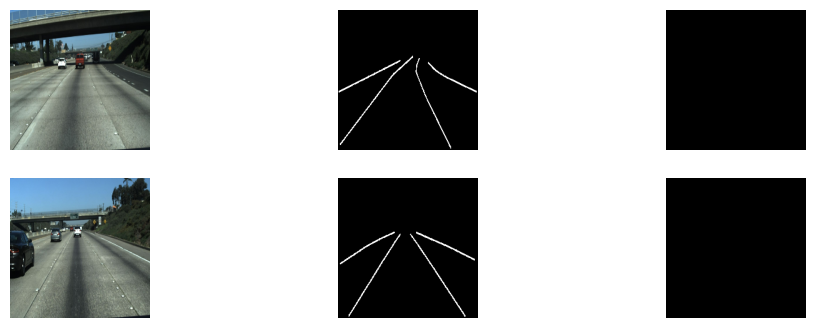

291/291 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.9707 - dice: 0.5593 - loss: 0.4407 - precision: 0.4848 - recall: 0.6624 - val_accuracy: 0.9727 - val_dice: 0.0057 - val_loss: 0.9944 - val_precision: 0.1937 - val_recall: 0.0028
Epoch 3/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9718 - dice: 0.5830 - loss: 0.4170 - precision: 0.5114 - recall: 0.6790

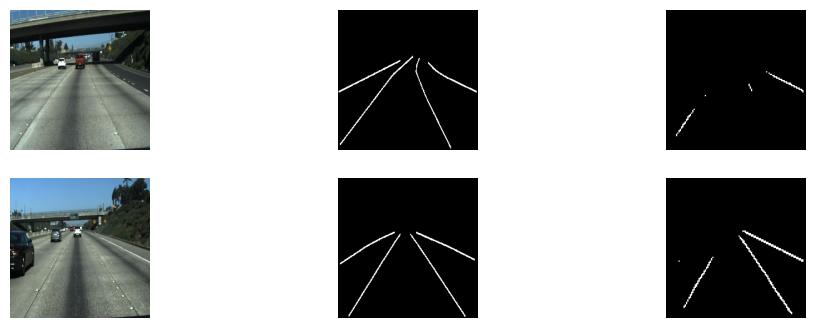

291/291 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.9718 - dice: 0.5830 - loss: 0.4170 - precision: 0.5115 - recall: 0.6790 - val_accuracy: 0.9726 - val_dice: 0.3944 - val_loss: 0.6057 - val_precision: 0.5206 - val_recall: 0.3210
Epoch 4/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9724 - dice: 0.5967 - loss: 0.4033 - precision: 0.5252 - recall: 0.6919

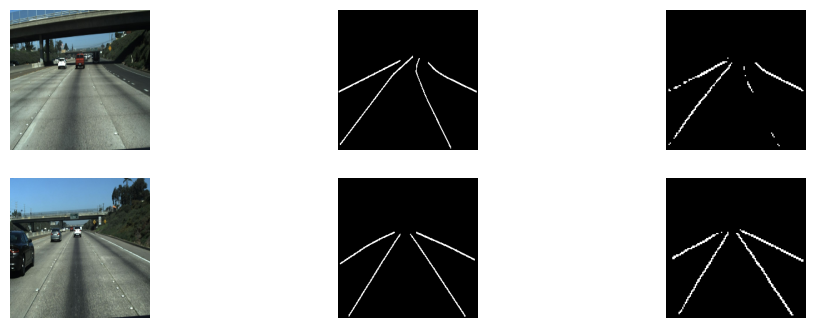

291/291 ━━━━━━━━━━━━━━━━━━━━ 44s 149ms/step - accuracy: 0.9724 - dice: 0.5967 - loss: 0.4033 - precision: 0.5252 - recall: 0.6919 - val_accuracy: 0.9721 - val_dice: 0.5140 - val_loss: 0.4860 - val_precision: 0.5133 - val_recall: 0.5167
Epoch 5/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9728 - dice: 0.6056 - loss: 0.3944 - precision: 0.5348 - recall: 0.6990

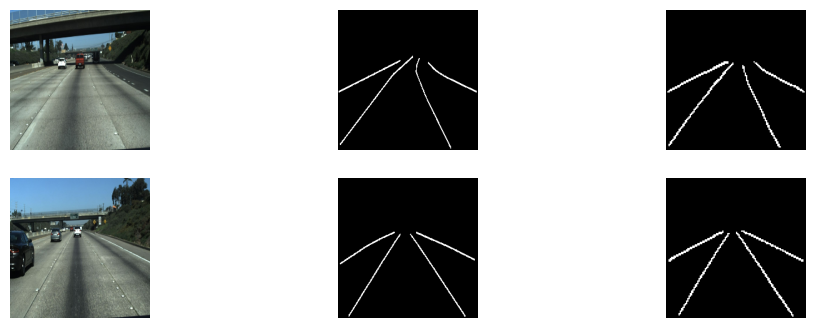

291/291 ━━━━━━━━━━━━━━━━━━━━ 44s 150ms/step - accuracy: 0.9728 - dice: 0.6056 - loss: 0.3944 - precision: 0.5348 - recall: 0.6990 - val_accuracy: 0.9718 - val_dice: 0.5849 - val_loss: 0.4152 - val_precision: 0.5136 - val_recall: 0.6798
Epoch 6/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9733 - dice: 0.6159 - loss: 0.3841 - precision: 0.5455 - recall: 0.7081

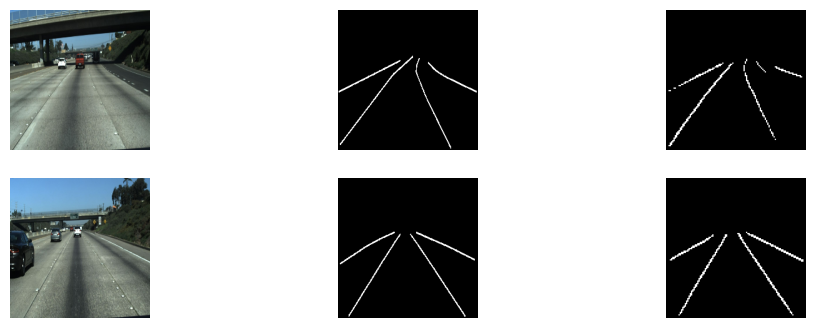

291/291 ━━━━━━━━━━━━━━━━━━━━ 42s 143ms/step - accuracy: 0.9733 - dice: 0.6159 - loss: 0.3841 - precision: 0.5455 - recall: 0.7081 - val_accuracy: 0.9726 - val_dice: 0.5340 - val_loss: 0.4660 - val_precision: 0.5274 - val_recall: 0.5423
Epoch 7/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9736 - dice: 0.6222 - loss: 0.3778 - precision: 0.5507 - recall: 0.7157

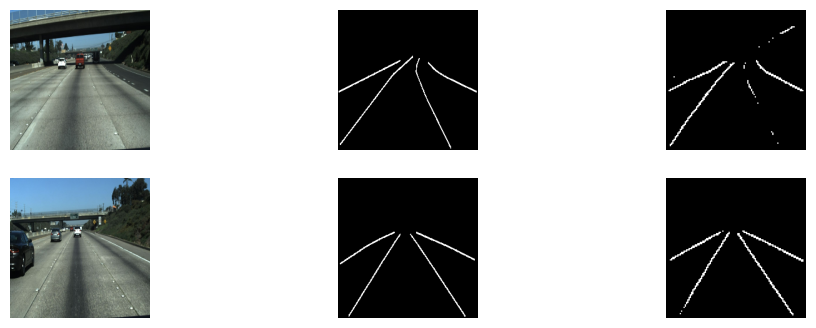

291/291 ━━━━━━━━━━━━━━━━━━━━ 42s 143ms/step - accuracy: 0.9736 - dice: 0.6222 - loss: 0.3778 - precision: 0.5507 - recall: 0.7157 - val_accuracy: 0.9721 - val_dice: 0.5256 - val_loss: 0.4744 - val_precision: 0.5173 - val_recall: 0.5365
Epoch 8/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9741 - dice: 0.6307 - loss: 0.3693 - precision: 0.5607 - recall: 0.7213

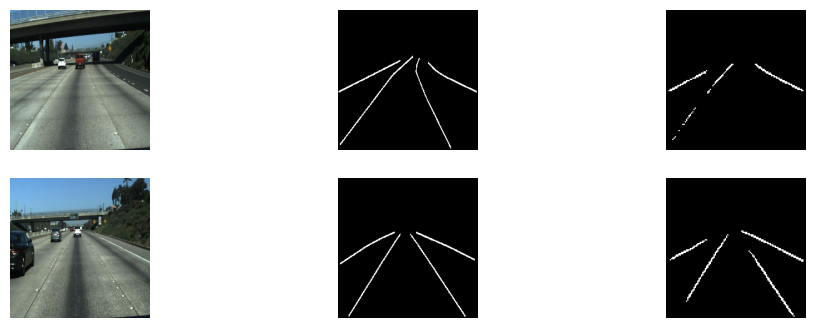

291/291 ━━━━━━━━━━━━━━━━━━━━ 42s 143ms/step - accuracy: 0.9741 - dice: 0.6307 - loss: 0.3693 - precision: 0.5607 - recall: 0.7213 - val_accuracy: 0.9727 - val_dice: 0.5327 - val_loss: 0.4672 - val_precision: 0.5321 - val_recall: 0.5365
Download trained model:


/kaggle/working/lane_model.h5

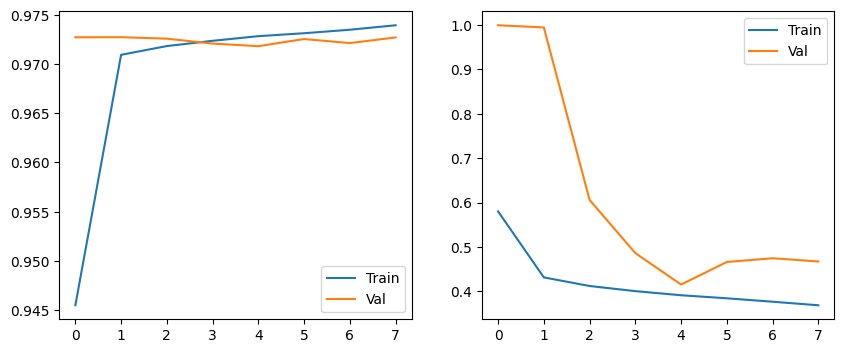

In [ ]:
from IPython.display import FileLink, display
class TrainingMonitor(Callback):
    def on_epoch_end(self, epoch, logs=None):
        for imgs, masks in val_set.take(1):
            preds = network.predict(imgs, verbose=0)
            preds = tf.round(preds)
            plt.figure(figsize=(12, 4))
            for i, (im, m, p) in enumerate(zip(imgs[:2], masks[:2], preds[:2])):
                plt.subplot(2, 3, i*3+1)
                plt.imshow(im)
                plt.axis('off')
                plt.subplot(2, 3, i*3+2)
                plt.imshow(m[..., 0], cmap='gray')
                plt.axis('off')
                plt.subplot(2, 3, i*3+3)
                plt.imshow(p[..., 0], cmap='gray')
                plt.axis('off')
            plt.show()

callbacks = [
    TrainingMonitor(),
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('lane_model.h5', save_best_only=True)
]

history = network.fit(train_set, validation_data=val_set, epochs=15, callbacks=callbacks)
print("Download trained model:")
display(FileLink('lane_model.h5'))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.savefig('training_progress.png')
plt.show()

#### 